# Twitter emotion detection: the notebook version

Companion to `notes/12_ml_pipelines_with_dvc.html` (video 02:41 – 02:46).

This is the **"traditional approach"**: the whole project in one notebook. The instructor walks through a notebook like this, then splits it into `src/` components run by DVC (see `../02_dvc_pipeline_walkthrough.ipynb`).

Steps: **ingest → text preprocessing → bag-of-words → XGBoost → evaluate**.

In [1]:
import os, re, string
import certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())   # macOS python.org builds need this for HTTPS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

for pkg in ("stopwords", "wordnet", "omw-1.4"):
    nltk.download(pkg, quiet=True)

## 1 · Data ingestion

In [2]:
DATA_URL = "https://raw.githubusercontent.com/entbappy/Branching-tutorial/refs/heads/master/tweet_emotions.csv"
df = pd.read_csv(DATA_URL)
print(df.shape)
df.head()

(40000, 3)


,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


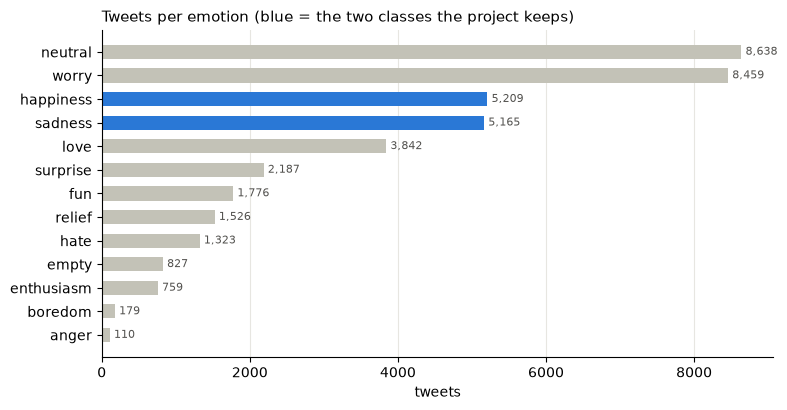

In [3]:
counts = df["sentiment"].value_counts()
kept = {"happiness", "sadness"}

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ["#2a78d6" if s in kept else "#c3c2b7" for s in counts.index]
bars = ax.barh(counts.index[::-1], counts.values[::-1], color=colors[::-1], height=0.6)
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=8, color="#52514e")
ax.set_title("Tweets per emotion (blue = the two classes the project keeps)", loc="left", fontsize=11)
ax.set_xlabel("tweets")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(axis="x", color="#e7e6e1", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The instructor keeps only **happiness (→ 1)** and **sadness (→ 0)** to make it a simple binary problem, and drops `tweet_id`.

In [4]:
data = df.drop(columns=["tweet_id"])
data = data[data["sentiment"].isin(["happiness", "sadness"])].copy()
data["sentiment"] = data["sentiment"].map({"happiness": 1, "sadness": 0})
# note: the course repo uses df['sentiment'].replace(..., inplace=True) on a filtered slice,
# which silently does nothing under pandas >= 3 (copy-on-write). .map() on a .copy() is safe.
print(data.shape)
print(data["sentiment"].value_counts().rename({1: "happiness (1)", 0: "sadness (0)"}))
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)
len(train_df), len(test_df)

(10374, 2)
sentiment
happiness (1)    5209
sadness (0)      5165
Name: count, dtype: int64


(8299, 2075)

## 2 · Text preprocessing
Lowercase → remove URLs → remove numbers → remove punctuation → drop stop words → lemmatise.

In [5]:
STOP = set(stopwords.words("english"))
LEM = WordNetLemmatizer()

def normalize_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans({c: " " for c in string.punctuation}))
    return " ".join(LEM.lemmatize(w) for w in text.split() if w not in STOP)

sample = "Watching 3 movies tonight!!! Check http://example.com - the kids were SO happy :)"
print("before:", sample)
print("after: ", normalize_text(sample))

before: Watching 3 movies tonight!!! Check http://example.com - the kids were SO happy :)


after:  watching movie tonight check kid happy


In [6]:
train_df["content"] = train_df["content"].map(normalize_text)
test_df["content"] = test_df["content"].map(normalize_text)
train_df = train_df[train_df["content"].str.len() > 0]
test_df = test_df[test_df["content"].str.len() > 0]
train_df.head()

,sentiment,content
23531,0,quot problem miss cause quot
8051,0,done already one proof nothing fair world
11499,0,hungry food steal
31288,1,foot hurt finally bed forget crunch productive...
18561,0,really ill atm


## 3 · Feature engineering: bag of words
Fit the vocabulary on **train only**, then transform both splits.

In [7]:
vectorizer = CountVectorizer(max_features=1000)
X_train = vectorizer.fit_transform(train_df["content"])
X_test = vectorizer.transform(test_df["content"])
y_train, y_test = train_df["sentiment"].values, test_df["sentiment"].values
print(X_train.shape, X_test.shape)
print("first vocabulary words:", list(vectorizer.get_feature_names_out()[:12]))

(8298, 1000) (2074, 1000)
first vocabulary words: ['able', 'absolutely', 'account', 'across', 'actually', 'add', 'adorable', 'afford', 'afternoon', 'age', 'ago', 'agree']


## 4 · Model building

In [8]:
model = XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric="logloss", random_state=42)
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 5 · Evaluation

In [9]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "auc": roc_auc_score(y_test, proba),
}
print(pd.Series(metrics).round(4).to_string())
cm = pd.DataFrame(confusion_matrix(y_test, pred),
                  index=["actual sadness", "actual happiness"],
                  columns=["pred sadness", "pred happiness"])
cm

accuracy     0.7392
precision    0.7975
recall       0.6252
auc          0.8367


,pred sadness,pred happiness
actual sadness,899,161
actual happiness,380,634


In [10]:
# which words push a tweet towards "happiness"? (XGBoost gain importance)
imp = pd.Series(model.get_booster().get_score(importance_type="gain"))
imp.index = [vectorizer.get_feature_names_out()[int(k[1:])] for k in imp.index]
imp.sort_values(ascending=False).head(10).round(1)

sad        71.2
thanks     50.8
happy      46.5
miss       41.4
awesome    32.8
good       32.0
suck       30.4
hurt       28.1
hate       27.5
thank      27.2
dtype: float64

In [11]:
def predict(texts):
    X = vectorizer.transform([normalize_text(t) for t in texts])
    return ["happiness" if p else "sadness" for p in model.predict(X)]

predict(["I love this sunny day with my friends", "I miss you so much, feeling lonely"])

['happiness', 'sadness']

## Why this notebook isn't enough for production

It works, but everything is in one place: no modularity, hard to collaborate on, hard to re-run only what changed.
The same code is split into five components in **`src/`** and wired together with **`dvc.yaml`**.
See **`02_dvc_pipeline_walkthrough.ipynb`** in the project root.

| Notebook section | Component | Output |
|---|---|---|
| 1 · ingestion | `src/data_ingestion.py` | `data/raw/` |
| 2 · preprocessing | `src/data_preprocessing.py` | `data/processed/` |
| 3 · features | `src/feature_engineering.py` | `data/features/` |
| 4 · model | `src/model_building.py` | `model.pkl` |
| 5 · evaluation | `src/model_evaluation.py` | `metrics.json` |